In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Divya\Downloads\spotify dataset.csv")
print(df.head())
print(df.shape)
print(df.columns)

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

In [5]:
import numpy as np
print(df.isnull().sum())
df = df.drop_duplicates()
df = df.dropna()

print("After cleaning, shape:", df.shape)

num_features = df.select_dtypes(include=np.number)
print("Numeric columns:\n", num_features.columns)

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64
After cleaning, shape: (32828, 23)
Numeric columns:
 Index(['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms'],
      dtype='object')


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(num_features)

print("Scaled feature shape:", scaled_features.shape)

Scaled feature shape: (32828, 13)


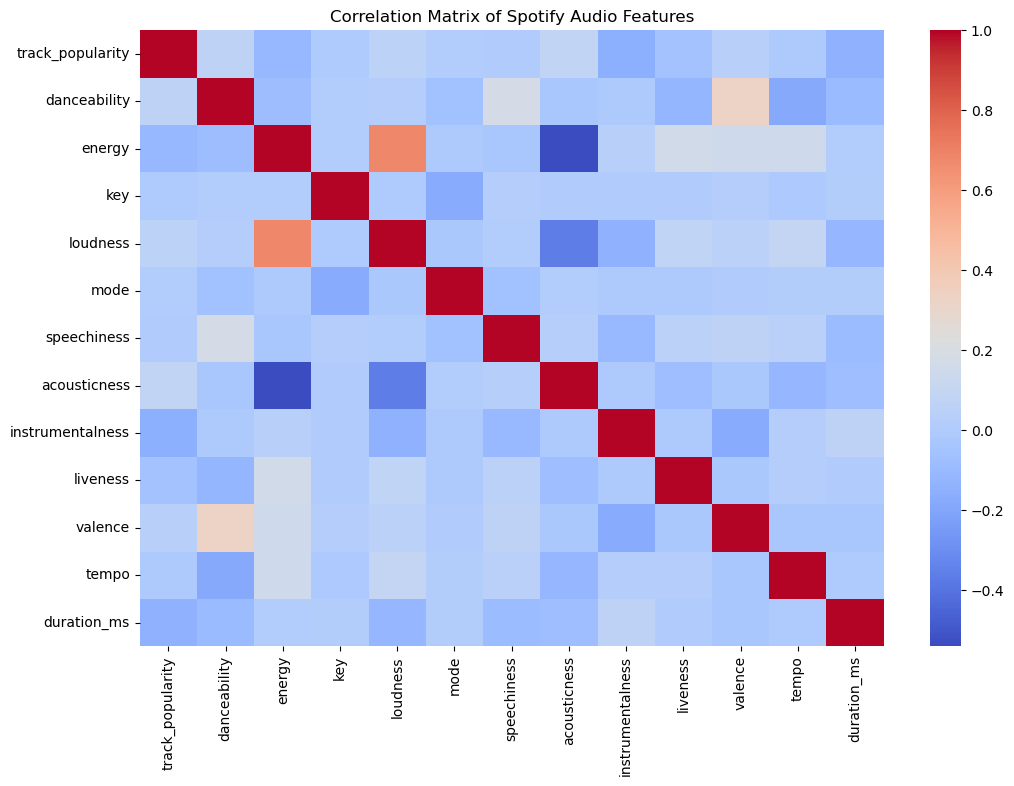

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(num_features.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Spotify Audio Features")
plt.show()

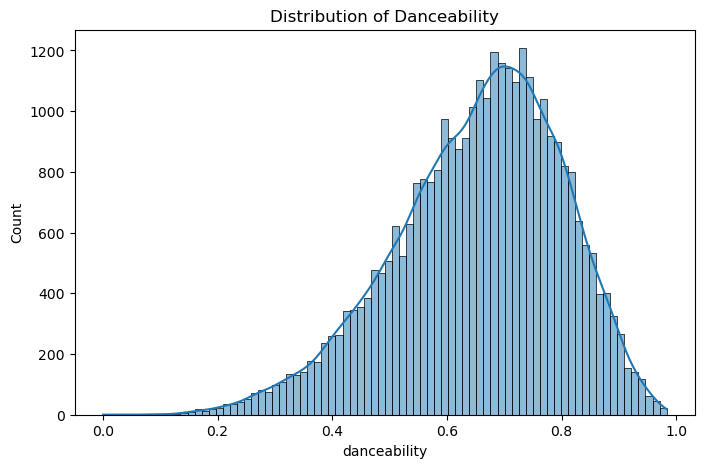

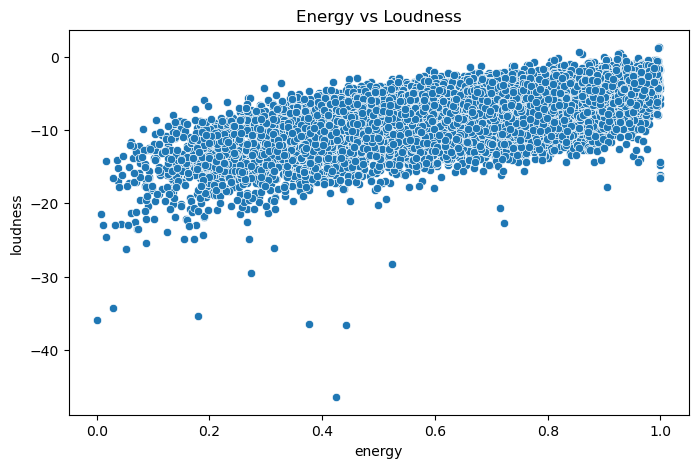

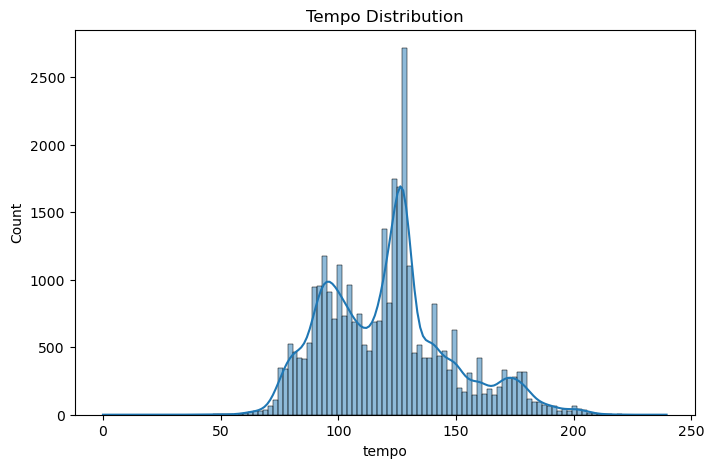

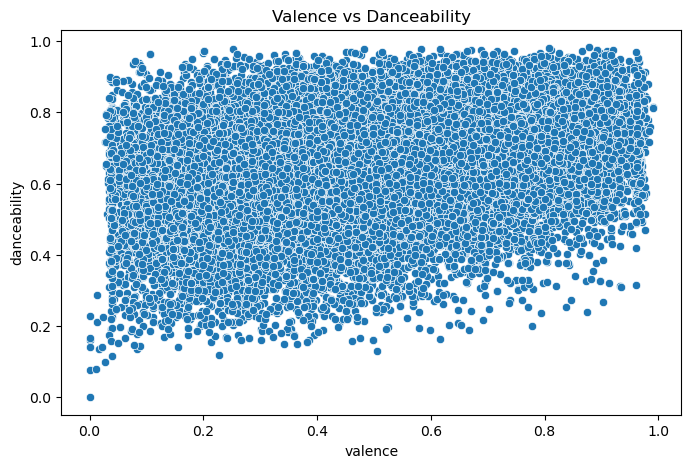

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['danceability'], kde=True)
plt.title("Distribution of Danceability")
plt.show()
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['energy'], y=df['loudness'])
plt.title("Energy vs Loudness")
plt.show()
 
plt.figure(figsize=(8, 5))
sns.histplot(df['tempo'], kde=True)
plt.title("Tempo Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['valence'], y=df['danceability'])
plt.title("Valence vs Danceability")
plt.show()

C:\Users\divya\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\divya\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\divya\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\divya\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

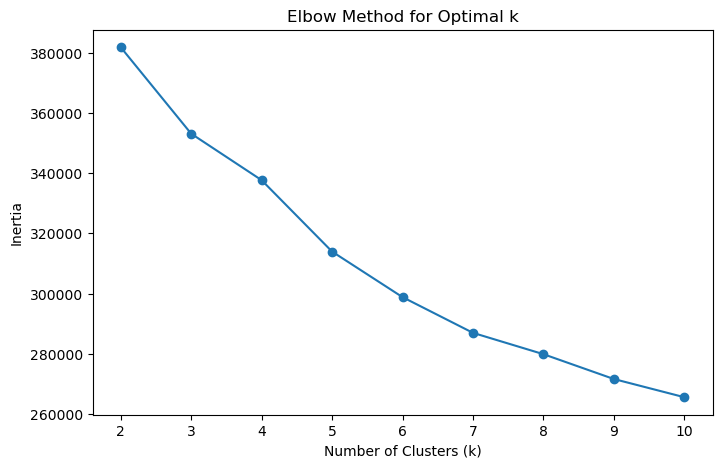

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)


df['Cluster'] = clusters


print(df['Cluster'].value_counts())

Cluster
2    12093
0     9609
1     6229
3     4897
Name: count, dtype: int64


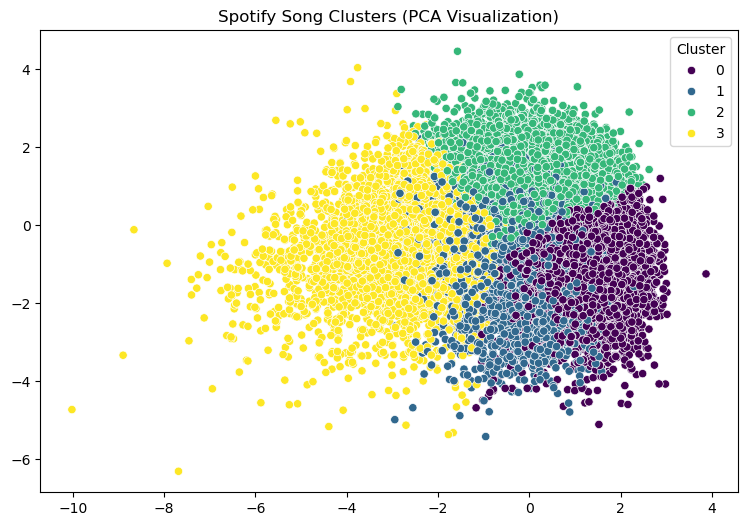

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Spotify Song Clusters (PCA Visualization)")
plt.show()

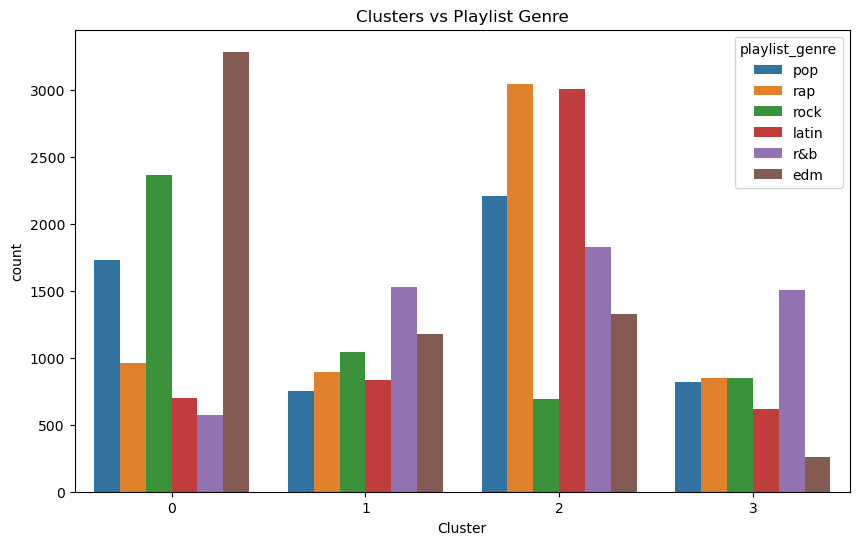

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue='playlist_genre', data=df)
plt.title("Clusters vs Playlist Genre")
plt.show()

In [14]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         track_popularity  danceability    energy       key   loudness  \
Cluster                                                                  
0               37.802477      0.542480  0.823788  5.154022  -5.096658   
1               20.428480      0.700133  0.691127  5.629154  -8.016110   
2               56.305053      0.741553  0.712376  5.480939  -5.840183   
3               45.591178      0.603636  0.428459  5.216663 -10.426226   

             mode  speechiness  acousticness  instrumentalness  liveness  \
Cluster                                                                    
0        0.592674     0.085046      0.060389          0.103147  0.254485   
1        0.561085     0.088078      0.103493          0.165567  0.156418   
2        0.529645     0.141284      0.159720          0.011171  0.169109   
3        0.607923     0.089842      0.530940          0.127619  0.158948   

          valence       tempo    duration_ms  
Cluster                                       
0   